In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import STL
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_score, recall_score, f1_score
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

## Load and Prepare Sensor Data

We load the sensor data from a CSV file, parse the timestamp column, and set it as the DataFrame index. This ensures our time series is properly indexed by time for analysis.

In [2]:
# Load data
df = pd.read_csv('dataset_time_Series/sensor.csv')

# Parse timestamp and set as index
df['timestamp_parsed'] = pd.to_datetime(df['timestamp'])
df = df.set_index('timestamp_parsed')

In [3]:
def evaluate_stl_anomaly_detection(sensor_name, residue_df, sensor_series, true_anomalies):
    # Get the residual values
    residuals = residue_df.iloc[:, 0].values  # Get the first column (residuals)
    
    # Calculate threshold using 3-sigma rule
    mean_val = np.mean(residuals)
    std_val = np.std(residuals)
    threshold = 3
    cutoff = mean_val + threshold * std_val
    
    # Create predicted anomalies array
    predicted_anomalies = (residuals > cutoff).astype(int)
    
    # Align the arrays to the same length
    min_length = min(len(predicted_anomalies), len(true_anomalies))
    predicted_anomalies = predicted_anomalies[:min_length]
    true_anomalies_aligned = true_anomalies[:min_length]
    
    # Calculate metrics
    accuracy = accuracy_score(true_anomalies_aligned, predicted_anomalies)
    precision = precision_score(true_anomalies_aligned, predicted_anomalies, zero_division=0)
    recall = recall_score(true_anomalies_aligned, predicted_anomalies, zero_division=0)
    f1 = f1_score(true_anomalies_aligned, predicted_anomalies, zero_division=0)
    
    # Create confusion matrix
    cm = confusion_matrix(true_anomalies_aligned, predicted_anomalies)
    
    # Print results
    print(f"\n{'='*60}")
    print(f"ANOMALY DETECTION RESULTS FOR {sensor_name.upper()}")
    print(f"{'='*60}")
    print(f"Threshold (mean + {threshold}*std): {cutoff:.4f}")
    print(f"Mean residual: {mean_val:.4f}")
    print(f"Std residual: {std_val:.4f}")
    print(f"\nPerformance Metrics:")
    print(f"Accuracy:  {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1-Score:  {f1:.4f}")
    
    # Plot confusion matrix
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['Normal', 'Anomaly'], 
                yticklabels=['Normal', 'Anomaly'])
    plt.title(f'Confusion Matrix - {sensor_name.upper()}')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.show()
    
    # Print detailed classification report
    print(f"\nDetailed Classification Report:")
    print(classification_report(true_anomalies_aligned, predicted_anomalies, 
                               target_names=['Normal', 'Anomaly'], zero_division=0))
    
    return {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1_score': f1,
        'confusion_matrix': cm,
        'threshold': cutoff
    }

## Visualize Sensor 10, 36 and 48 Readings Over Time

We plot the raw readings from sensor 10, 36 and 48 to get an initial sense of the data, trends, and any visible anomalies or patterns.

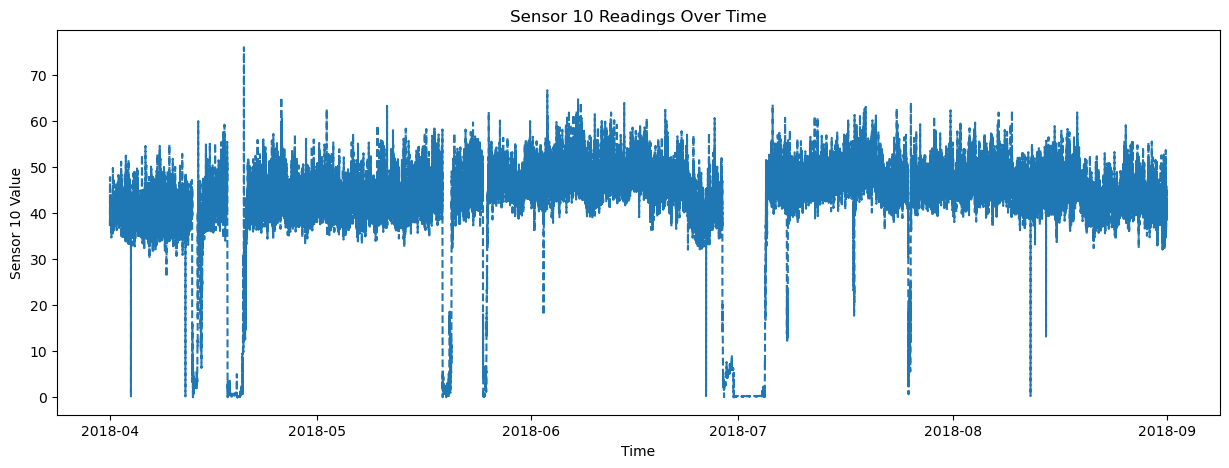

In [4]:
#displaying the sensor 10 data over time
plt.figure(figsize=(15,5))
plt.plot(df['sensor_10'], linestyle='--')
plt.title('Sensor 10 Readings Over Time')
plt.xlabel('Time')
plt.ylabel('Sensor 10 Value')
plt.show()

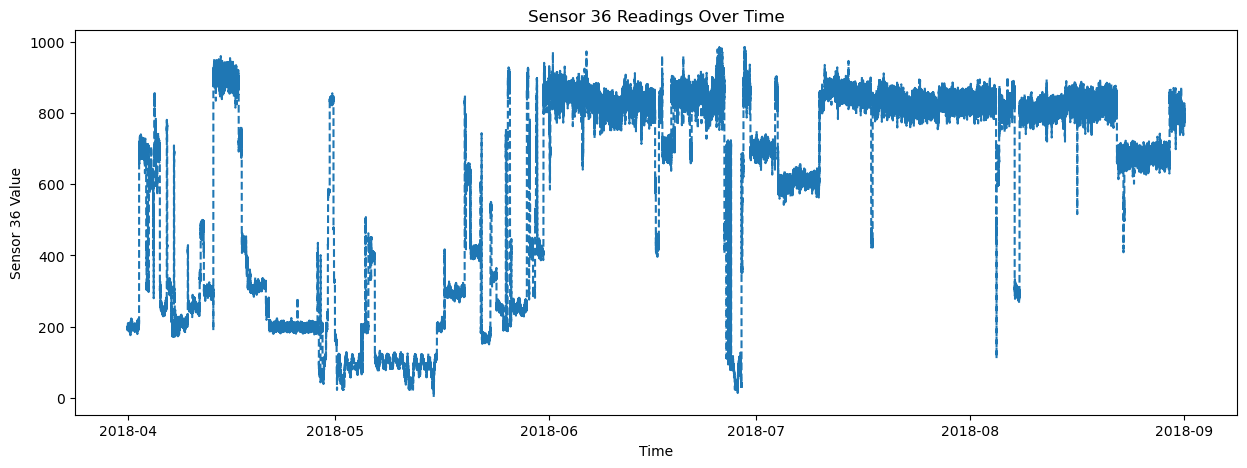

In [5]:
#displaying the sensor 36 data over time
plt.figure(figsize=(15,5))
plt.plot(df['sensor_36'], linestyle='--')
plt.title('Sensor 36 Readings Over Time')
plt.xlabel('Time')
plt.ylabel('Sensor 36 Value')
plt.show()

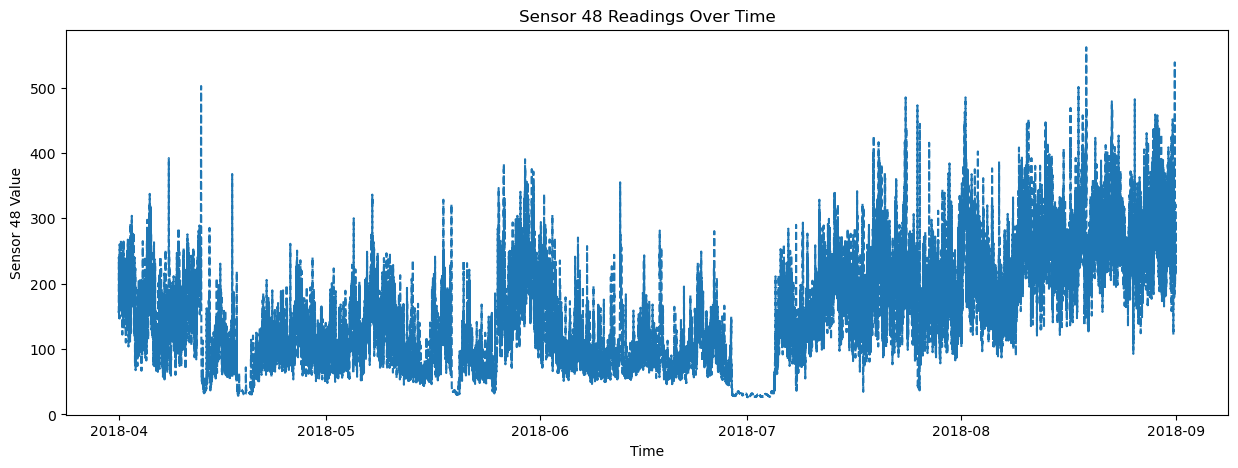

In [6]:
#displaying the sensor 48 data over time
plt.figure(figsize=(15,5))
plt.plot(df['sensor_48'], linestyle='--')
plt.title('Sensor 48 Readings Over Time')
plt.xlabel('Time')
plt.ylabel('Sensor 48 Value')
plt.show()

## STL Decomposition: Seasonal-Trend Decomposition using Loess

STL (Seasonal-Trend decomposition using Loess) is a powerful method for decomposing a time series into three distinct components: **trend**, **seasonality**, and **residual (remainder)**. This helps us better understand the underlying patterns in the data and isolate anomalies.

### What is STL Decomposition?
- **Trend:** The long-term progression or movement in the data (e.g., an overall increase or decrease over time).
- **Seasonality:** Regular, repeating patterns or cycles in the data (e.g., daily, weekly, or yearly effects).
- **Residual (Remainder):** The part of the data that remains after removing trend and seasonality—this is where anomalies and irregularities are most visible.

### Why Use STL?
- STL is robust and flexible, able to handle any type of seasonality (not just fixed periods).
- It uses LOESS (locally estimated scatterplot smoothing) to fit smooth curves to the trend and seasonal components.
- By separating the time series into these components, we can analyze each part individually and more effectively detect anomalies in the residuals.

### How Does STL Work?
1. **Decompose the time series** into trend, seasonal, and residual components using the STL algorithm.
2. **Analyze the components**:
   - The trend shows the overall direction of the data.
   - The seasonal component reveals repeating cycles.
   - The residual captures noise and potential anomalies.

### Visualization
- The original series, trend, seasonal, and residual components are plotted for visual inspection.
- Anomalies are typically detected in the residual component, as it represents the "unexplained" part of the data.

STL decomposition is a foundational tool in time series analysis, enabling clearer insights and more accurate anomaly detection by isolating different sources of variation in the data.


# STL Decomposition and anomaly detection of Sensor 10

In [7]:
# Perform STL decomposition on sensor_10
sensor_series = df['sensor_10'].dropna()  # Remove any NaN values
result = STL(sensor_series, period=24).fit()

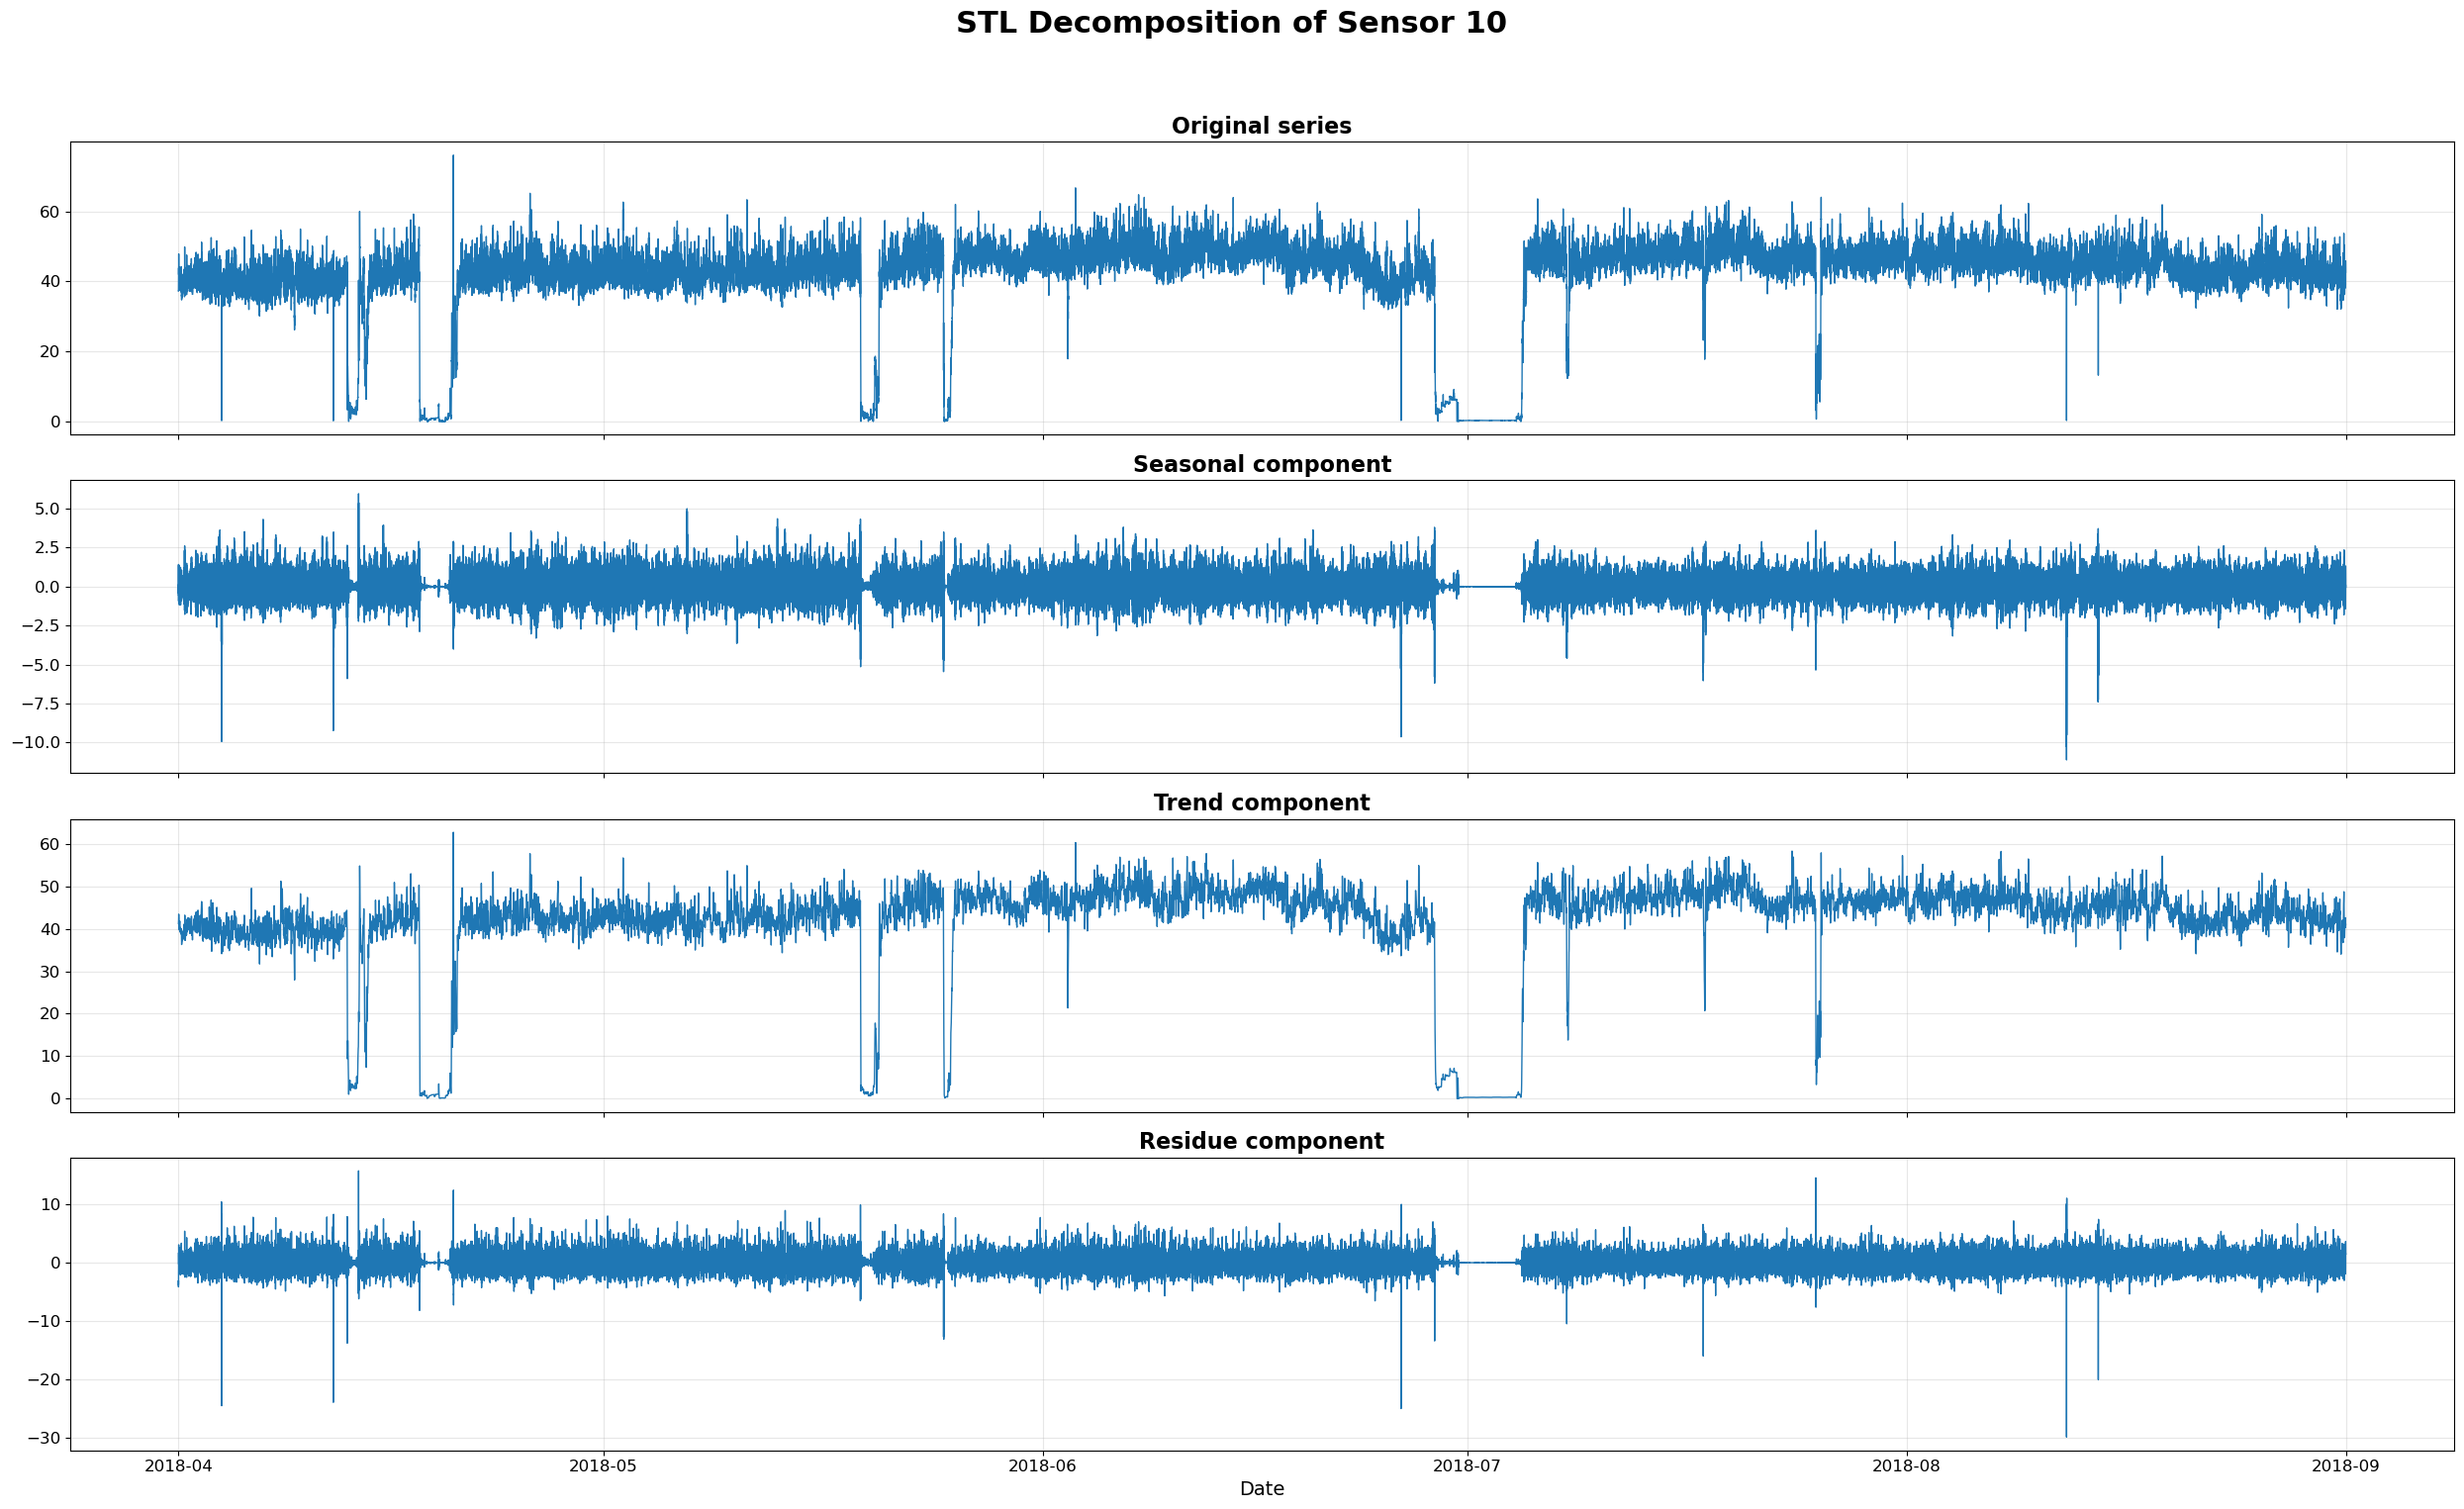

In [8]:
title_list = ['Original series', 'Seasonal component', 'Trend component', 'Residue component']

components = [result.observed, result.seasonal, result.trend, result.resid]

fig, axes = plt.subplots(4, 1, figsize=(25, 16), sharex=True)

for i, (ax, comp, title) in enumerate(zip(axes, components, title_list)):
    ax.plot(comp, linewidth=1, markersize=2)  # Reduce line width and marker size
    ax.set_title(title, fontsize=16, fontweight='bold')
    ax.tick_params(axis='both', labelsize=12)
    ax.grid(True, alpha=0.3)
    if i < 3:
        ax.set_xlabel('')
    else:
        ax.set_xlabel('Date', fontsize=14)

plt.suptitle('STL Decomposition of Sensor 10', fontsize=22, fontweight='bold')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

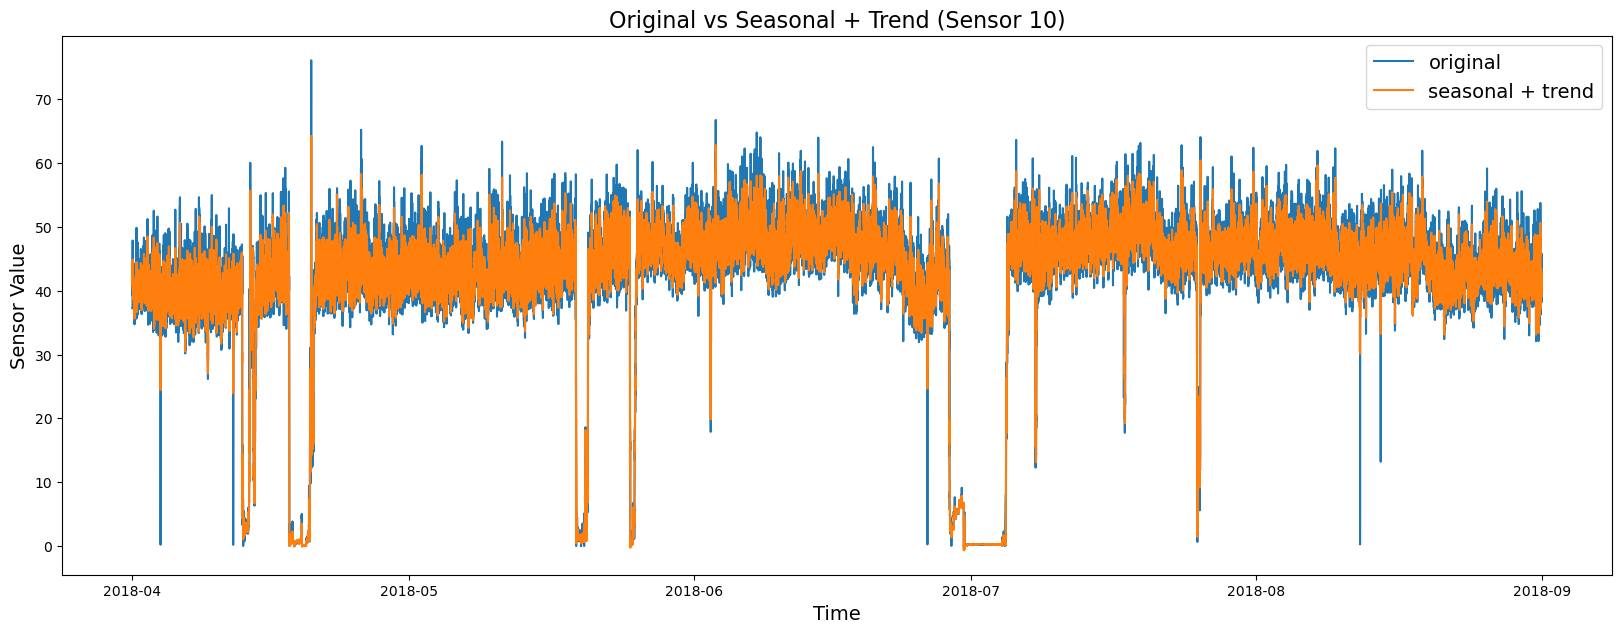

In [9]:
plt.figure(figsize=(20,7))
plt.plot(sensor_series, label="original", zorder=1)
plt.plot(result.trend + result.seasonal, label="seasonal + trend", zorder=2)
plt.title('Original vs Seasonal + Trend (Sensor 10)', fontsize=16)
plt.xlabel('Time', fontsize=14)
plt.ylabel('Sensor Value', fontsize=14)
plt.legend(fontsize=14)
plt.show()

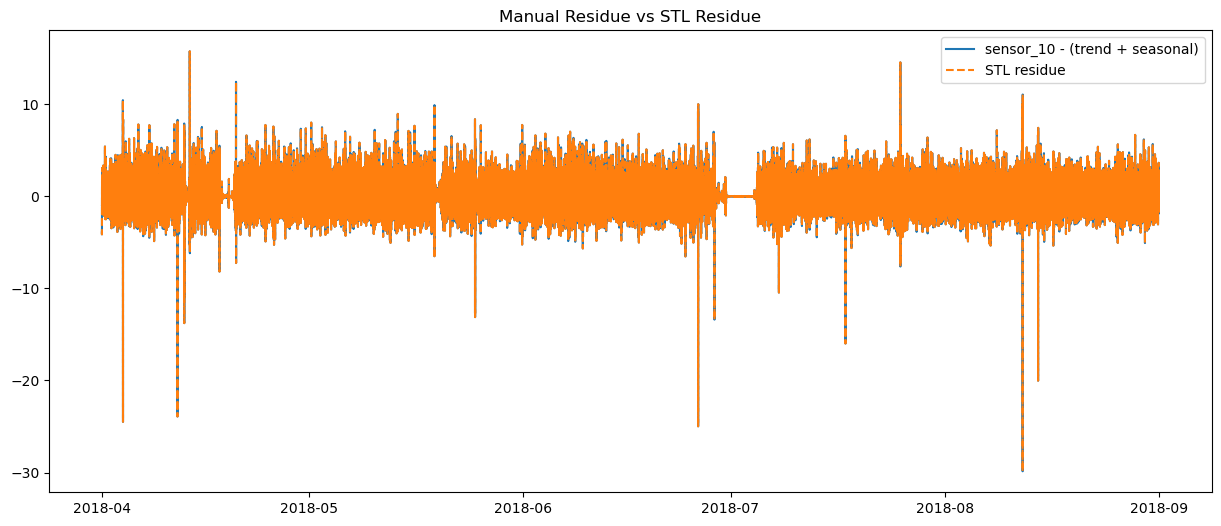

In [10]:
# Compare manual residue calculation with STL residue
manual_resid = sensor_series - (result.trend + result.seasonal)
plt.figure(figsize=(15, 6))
plt.plot(manual_resid, label='sensor_10 - (trend + seasonal)')
plt.plot(result.resid, label='STL residue', linestyle='--')
plt.legend()
plt.title('Manual Residue vs STL Residue')
plt.show()

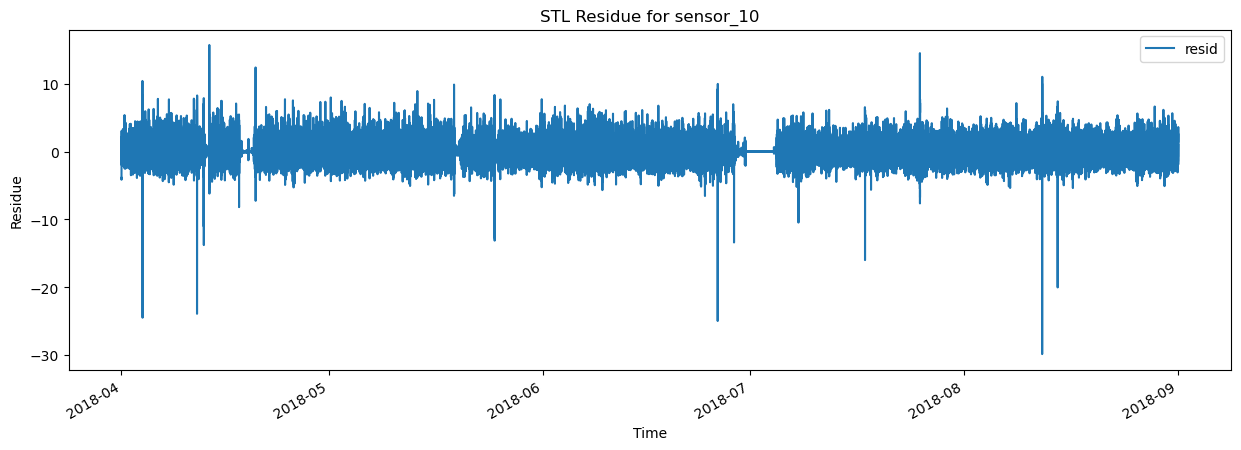

In [11]:
residue_df = pd.DataFrame(result.resid)
residue_df = residue_df.rename(columns={0: 'sensor_10'})  # If the column is unnamed

residue_df.plot(figsize=(15, 5), title='STL Residue for sensor_10')
plt.xlabel('Time')
plt.ylabel('Residue')
plt.show()

In [12]:
  def detect_anomalies_using_mean_std_method(data, plot_cutoff=True):
      if isinstance(data, pd.DataFrame):
          series = data.iloc[:, 0]
      else:
          series = data
      mean_val = series.mean()
      std_val = series.std()
      threshold = 3
      cutoff = mean_val + threshold * std_val
      print(f"Mean value = {mean_val:.2f}, Standard deviation value = {std_val:.2f}, Cutoff value = {cutoff:.2f}")
      anomaly_array = np.where(series > cutoff, 1, np.nan)
      if plot_cutoff:
          plt.figure(figsize=(15, 5))
          plt.plot(series, label='Data')
          plt.axhline(cutoff, color='red', linestyle='--', label=f'Cutoff ({cutoff:.2f})')
          plt.fill_between(series.index, 0, cutoff, color='green', alpha=0.2, label='Normal Region')
          plt.title('Anomaly Detection using Mean-Std Method')
          plt.legend()
          plt.show()
      return anomaly_array

Mean value = -0.00, Standard deviation value = 1.25, Cutoff value = 3.74


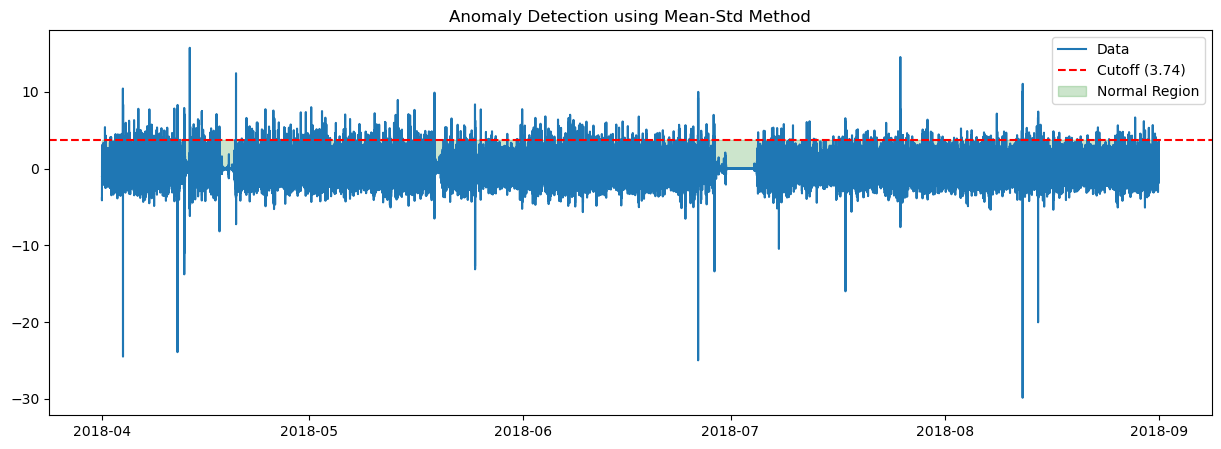

In [13]:
 anomaly_array = detect_anomalies_using_mean_std_method(residue_df, plot_cutoff=True)

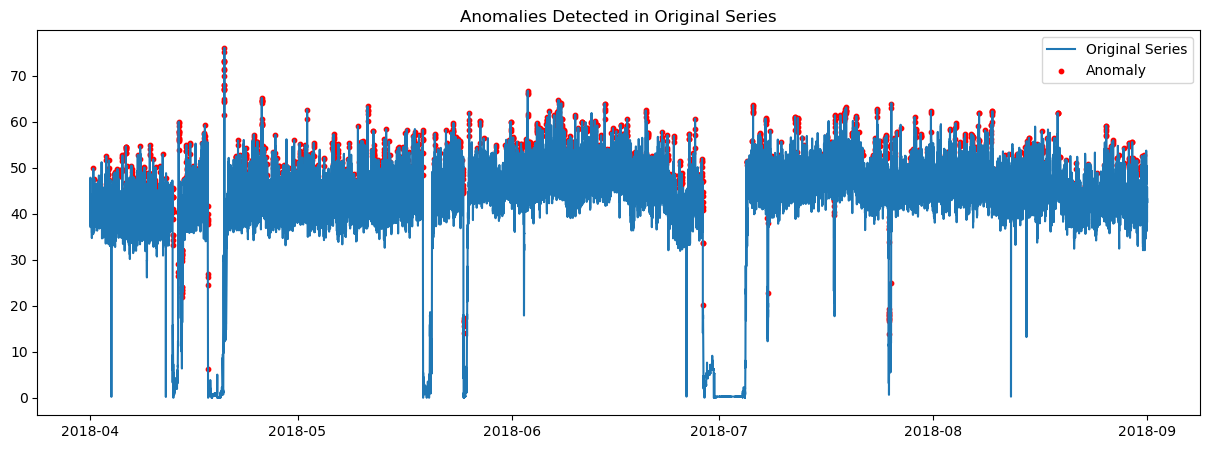

In [14]:
anomaly_indices = residue_df.index[~np.isnan(anomaly_array)]
plt.figure(figsize=(15,5))
plt.plot(sensor_series, label='Original Series')
plt.scatter(anomaly_indices, sensor_series.loc[anomaly_indices], color='red', label='Anomaly', s=10)
plt.legend()
plt.title('Anomalies Detected in Original Series')
plt.show()

EVALUATING SENSOR 10:

ANOMALY DETECTION RESULTS FOR SENSOR_10
Threshold (mean + 3*std): 3.7418
Mean residual: -0.0001
Std residual: 1.2473

Performance Metrics:
Accuracy:  0.9275
Precision: 0.0206
Recall:    0.0022
F1-Score:  0.0040


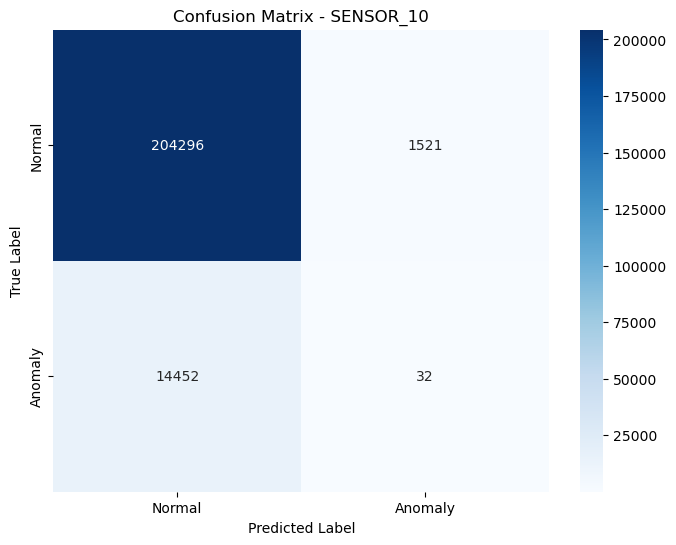


Detailed Classification Report:
              precision    recall  f1-score   support

      Normal       0.93      0.99      0.96    205817
     Anomaly       0.02      0.00      0.00     14484

    accuracy                           0.93    220301
   macro avg       0.48      0.50      0.48    220301
weighted avg       0.87      0.93      0.90    220301



In [16]:
true_anomalies = (df['machine_status'] != 'NORMAL').astype(int)
print("EVALUATING SENSOR 10:")
results_sensor_10 = evaluate_stl_anomaly_detection('sensor_10', residue_df, sensor_series, true_anomalies)

In [17]:
# For sensor 10
residue_df_10 = residue_df.copy()  # or whatever your residual DataFrame is called at this point

# STL Decomposition and anomaly detection of Sensor 36

In [18]:
# Perform STL decomposition on sensor_36
sensor_series = df['sensor_36'].dropna()  # Remove any NaN values
result = STL(sensor_series, period=24).fit()

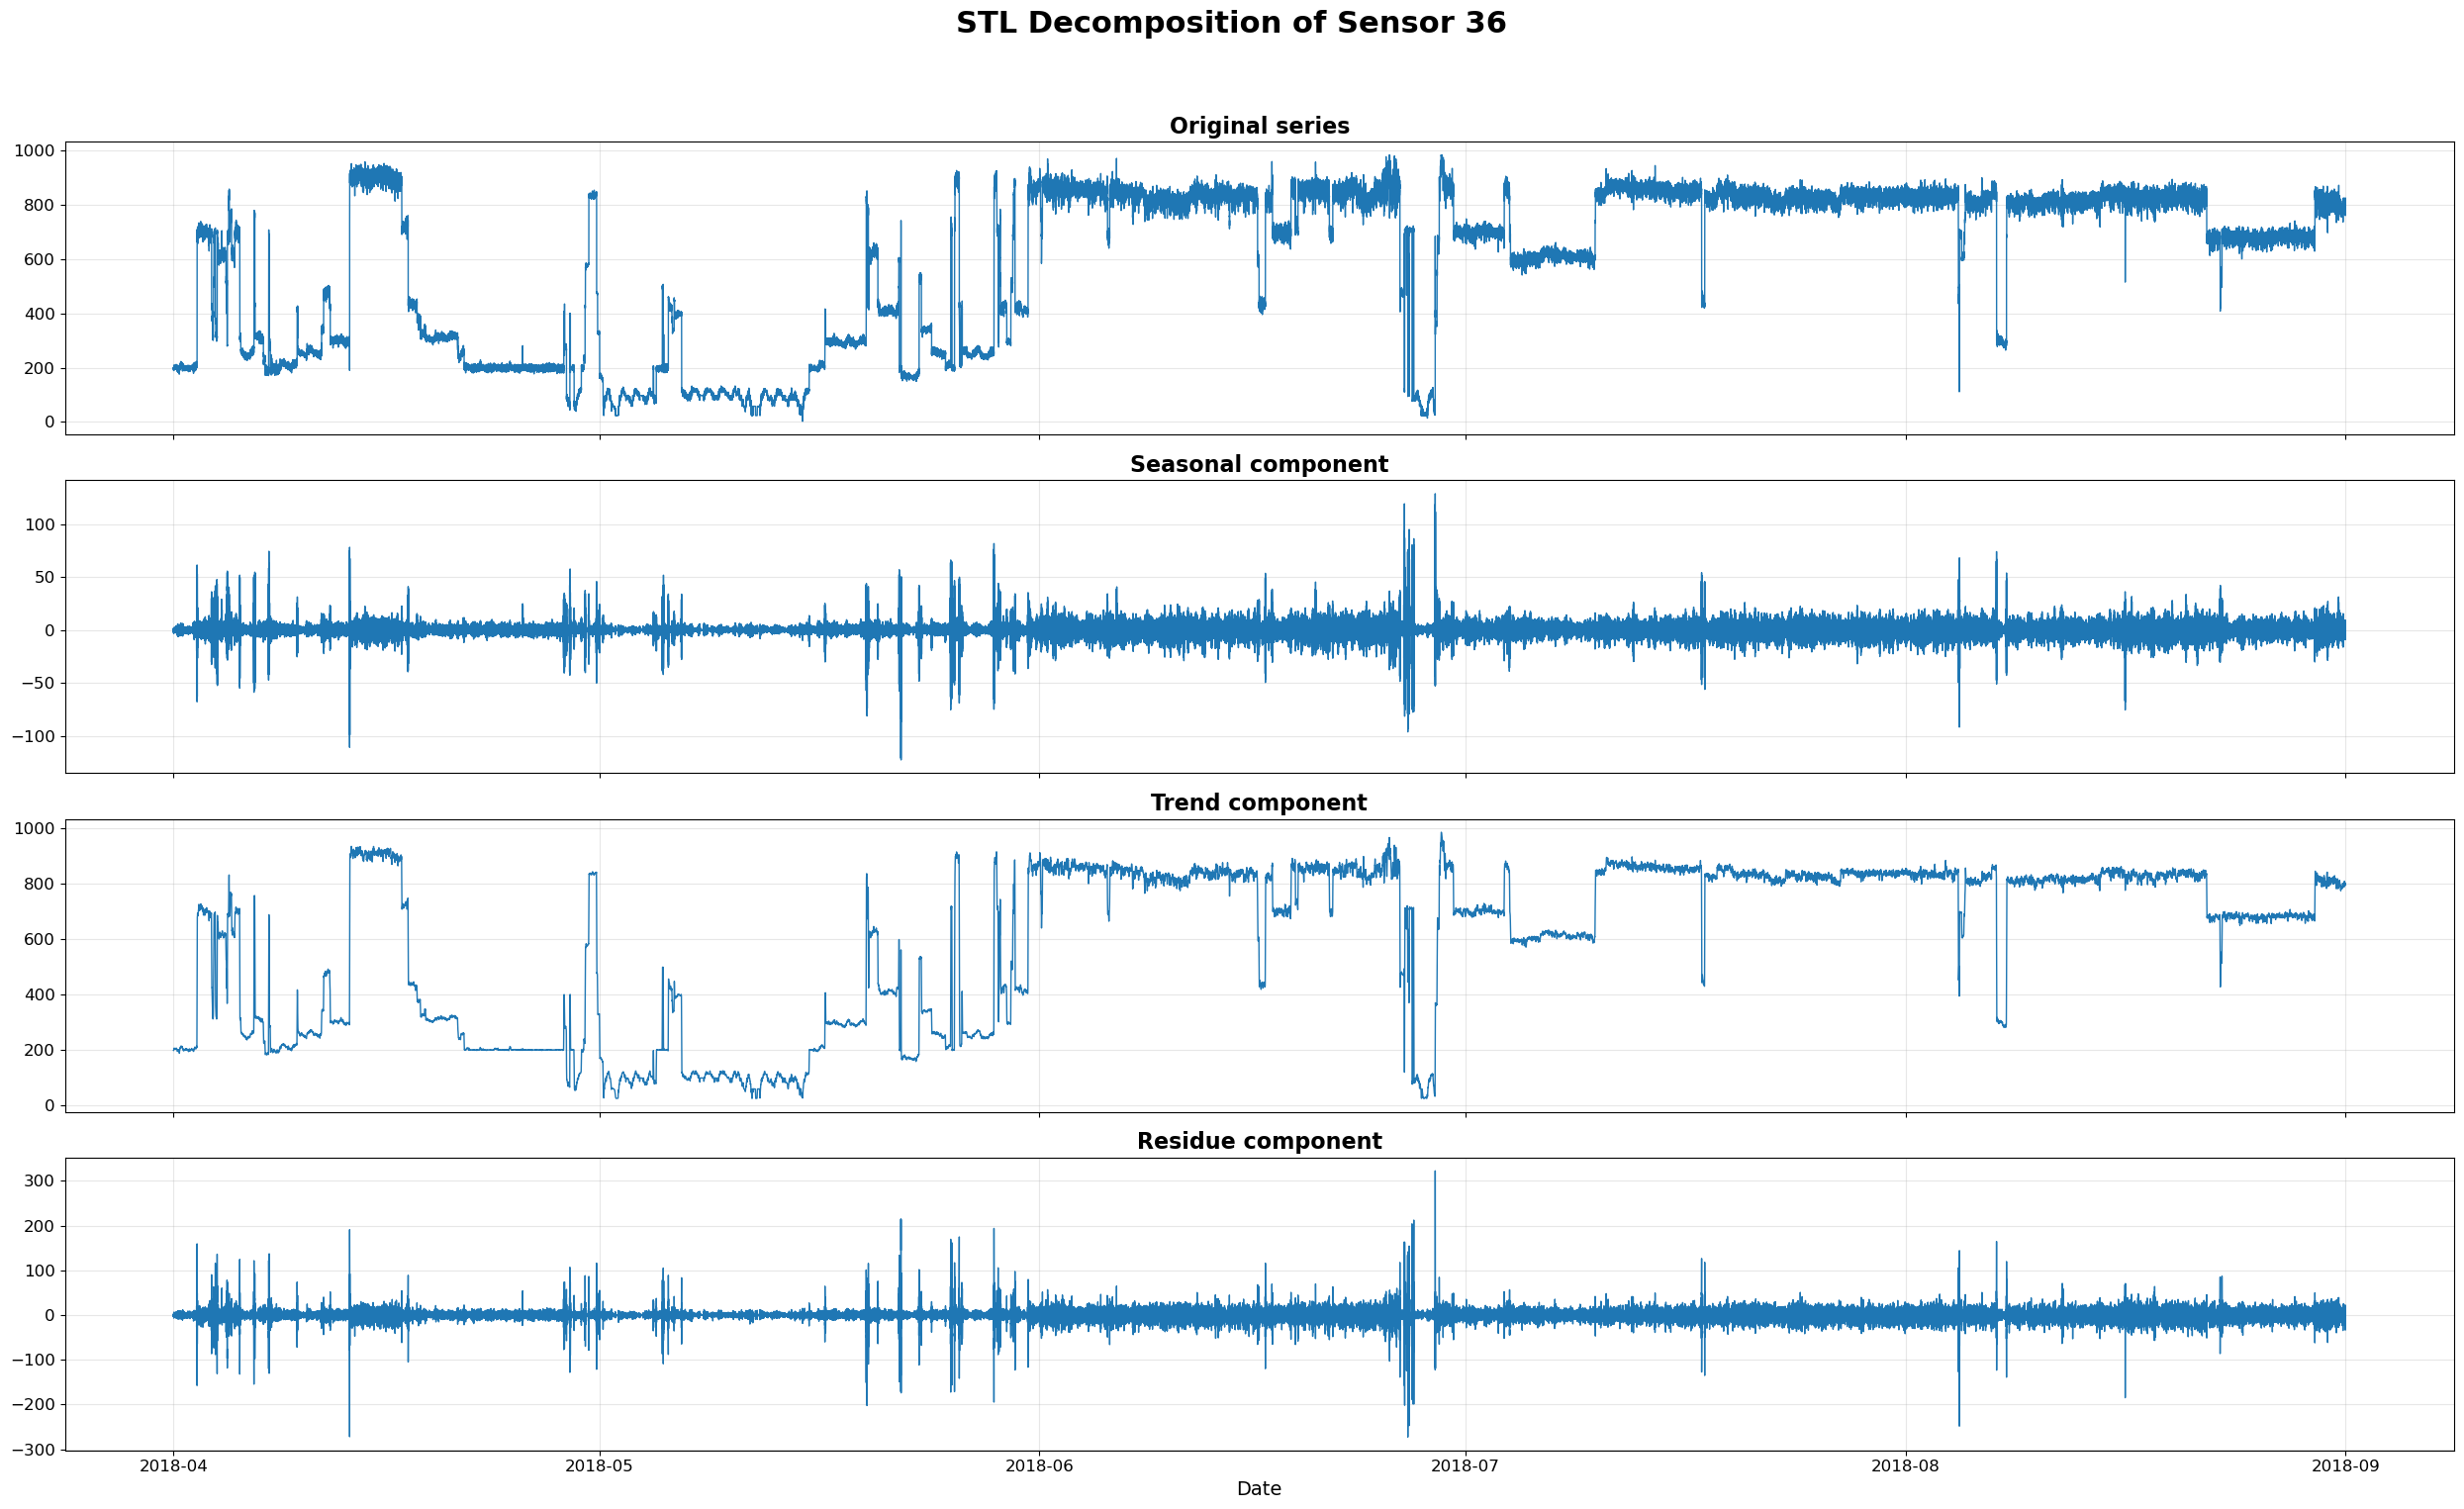

In [19]:
title_list = ['Original series', 'Seasonal component', 'Trend component', 'Residue component']

components = [result.observed, result.seasonal, result.trend, result.resid]

fig, axes = plt.subplots(4, 1, figsize=(25, 16), sharex=True)

for i, (ax, comp, title) in enumerate(zip(axes, components, title_list)):
    ax.plot(comp, linewidth=1, markersize=2)  # Reduce line width and marker size
    ax.set_title(title, fontsize=16, fontweight='bold')
    ax.tick_params(axis='both', labelsize=12)
    ax.grid(True, alpha=0.3)
    if i < 3:
        ax.set_xlabel('')
    else:
        ax.set_xlabel('Date', fontsize=14)

plt.suptitle('STL Decomposition of Sensor 36', fontsize=22, fontweight='bold')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

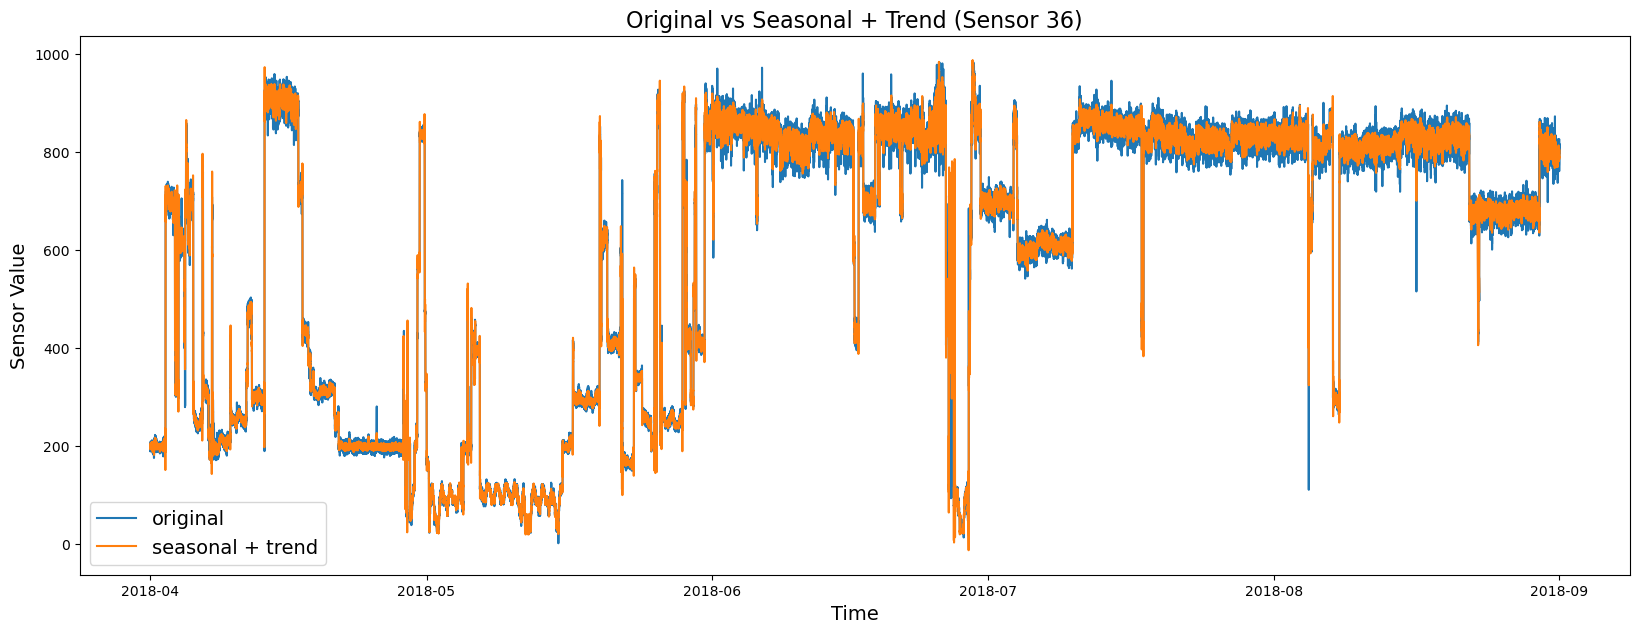

In [20]:
plt.figure(figsize=(20,7))
plt.plot(sensor_series, label="original", zorder=1)
plt.plot(result.trend + result.seasonal, label="seasonal + trend", zorder=2)
plt.title('Original vs Seasonal + Trend (Sensor 36)', fontsize=16)
plt.xlabel('Time', fontsize=14)
plt.ylabel('Sensor Value', fontsize=14)
plt.legend(fontsize=14)
plt.show()

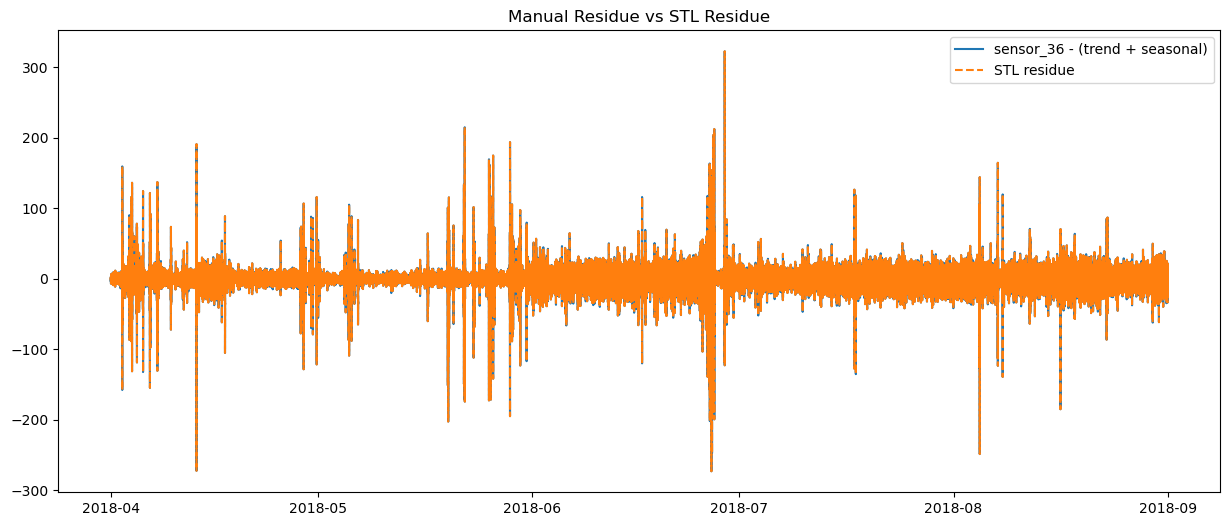

In [21]:
# Compare manual residue calculation with STL residue
manual_resid = sensor_series - (result.trend + result.seasonal)
plt.figure(figsize=(15, 6))
plt.plot(manual_resid, label='sensor_36 - (trend + seasonal)')
plt.plot(result.resid, label='STL residue', linestyle='--')
plt.legend()
plt.title('Manual Residue vs STL Residue')
plt.show()

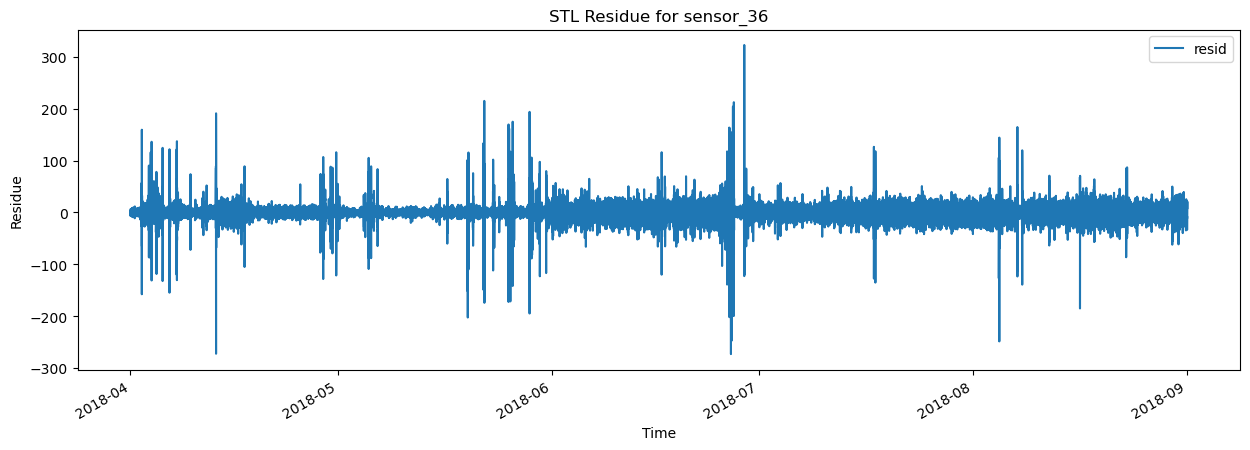

In [22]:
residue_df = pd.DataFrame(result.resid)
residue_df = residue_df.rename(columns={0: 'sensor_36'})  # If the column is unnamed

residue_df.plot(figsize=(15, 5), title='STL Residue for sensor_36')
plt.xlabel('Time')
plt.ylabel('Residue')
plt.show()

Mean value = -0.00, Standard deviation value = 12.35, Cutoff value = 37.05


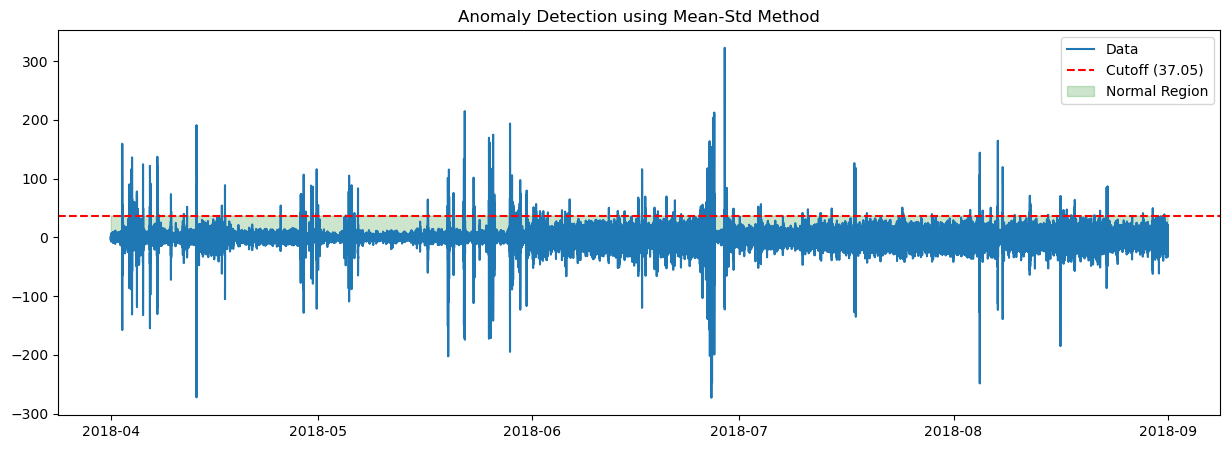

In [23]:
 anomaly_array = detect_anomalies_using_mean_std_method(residue_df, plot_cutoff=True)

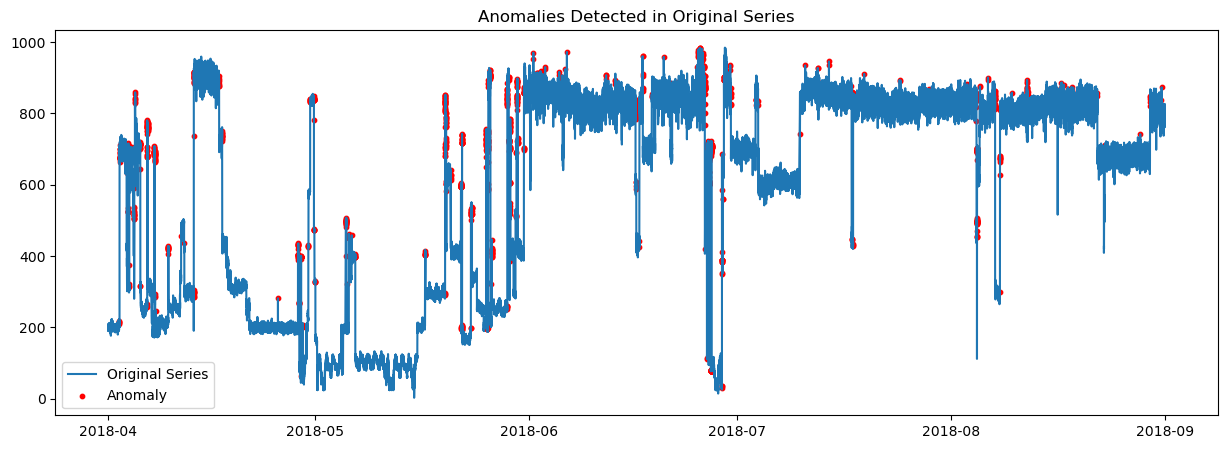

In [24]:
anomaly_indices = residue_df.index[~np.isnan(anomaly_array)]
plt.figure(figsize=(15,5))
plt.plot(sensor_series, label='Original Series')
plt.scatter(anomaly_indices, sensor_series.loc[anomaly_indices], color='red', label='Anomaly', s=10)
plt.legend()
plt.title('Anomalies Detected in Original Series')
plt.show()

EVALUATING SENSOR 36:

ANOMALY DETECTION RESULTS FOR SENSOR_36
Threshold (mean + 3*std): 37.0547
Mean residual: -0.0002
Std residual: 12.3516

Performance Metrics:
Accuracy:  0.9286
Precision: 0.0833
Recall:    0.0086
F1-Score:  0.0155


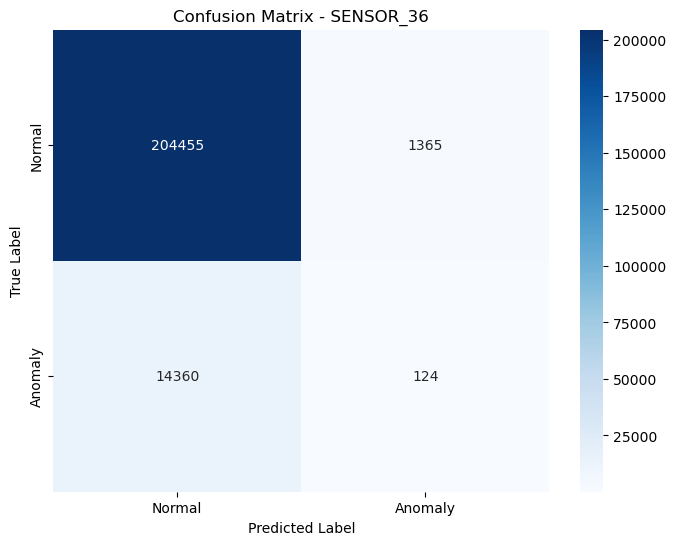


Detailed Classification Report:
              precision    recall  f1-score   support

      Normal       0.93      0.99      0.96    205820
     Anomaly       0.08      0.01      0.02     14484

    accuracy                           0.93    220304
   macro avg       0.51      0.50      0.49    220304
weighted avg       0.88      0.93      0.90    220304



In [25]:
print("EVALUATING SENSOR 36:")
results_sensor_36 = evaluate_stl_anomaly_detection('sensor_36', residue_df, sensor_series, true_anomalies)

In [26]:
# For sensor 36
residue_df_36 = residue_df.copy()

# STL Decomposition and anomaly detection of Sensor 48

In [27]:
# Perform STL decomposition on sensor_48
sensor_series = df['sensor_48'].dropna()  # Remove any NaN values
result = STL(sensor_series, period=24).fit()

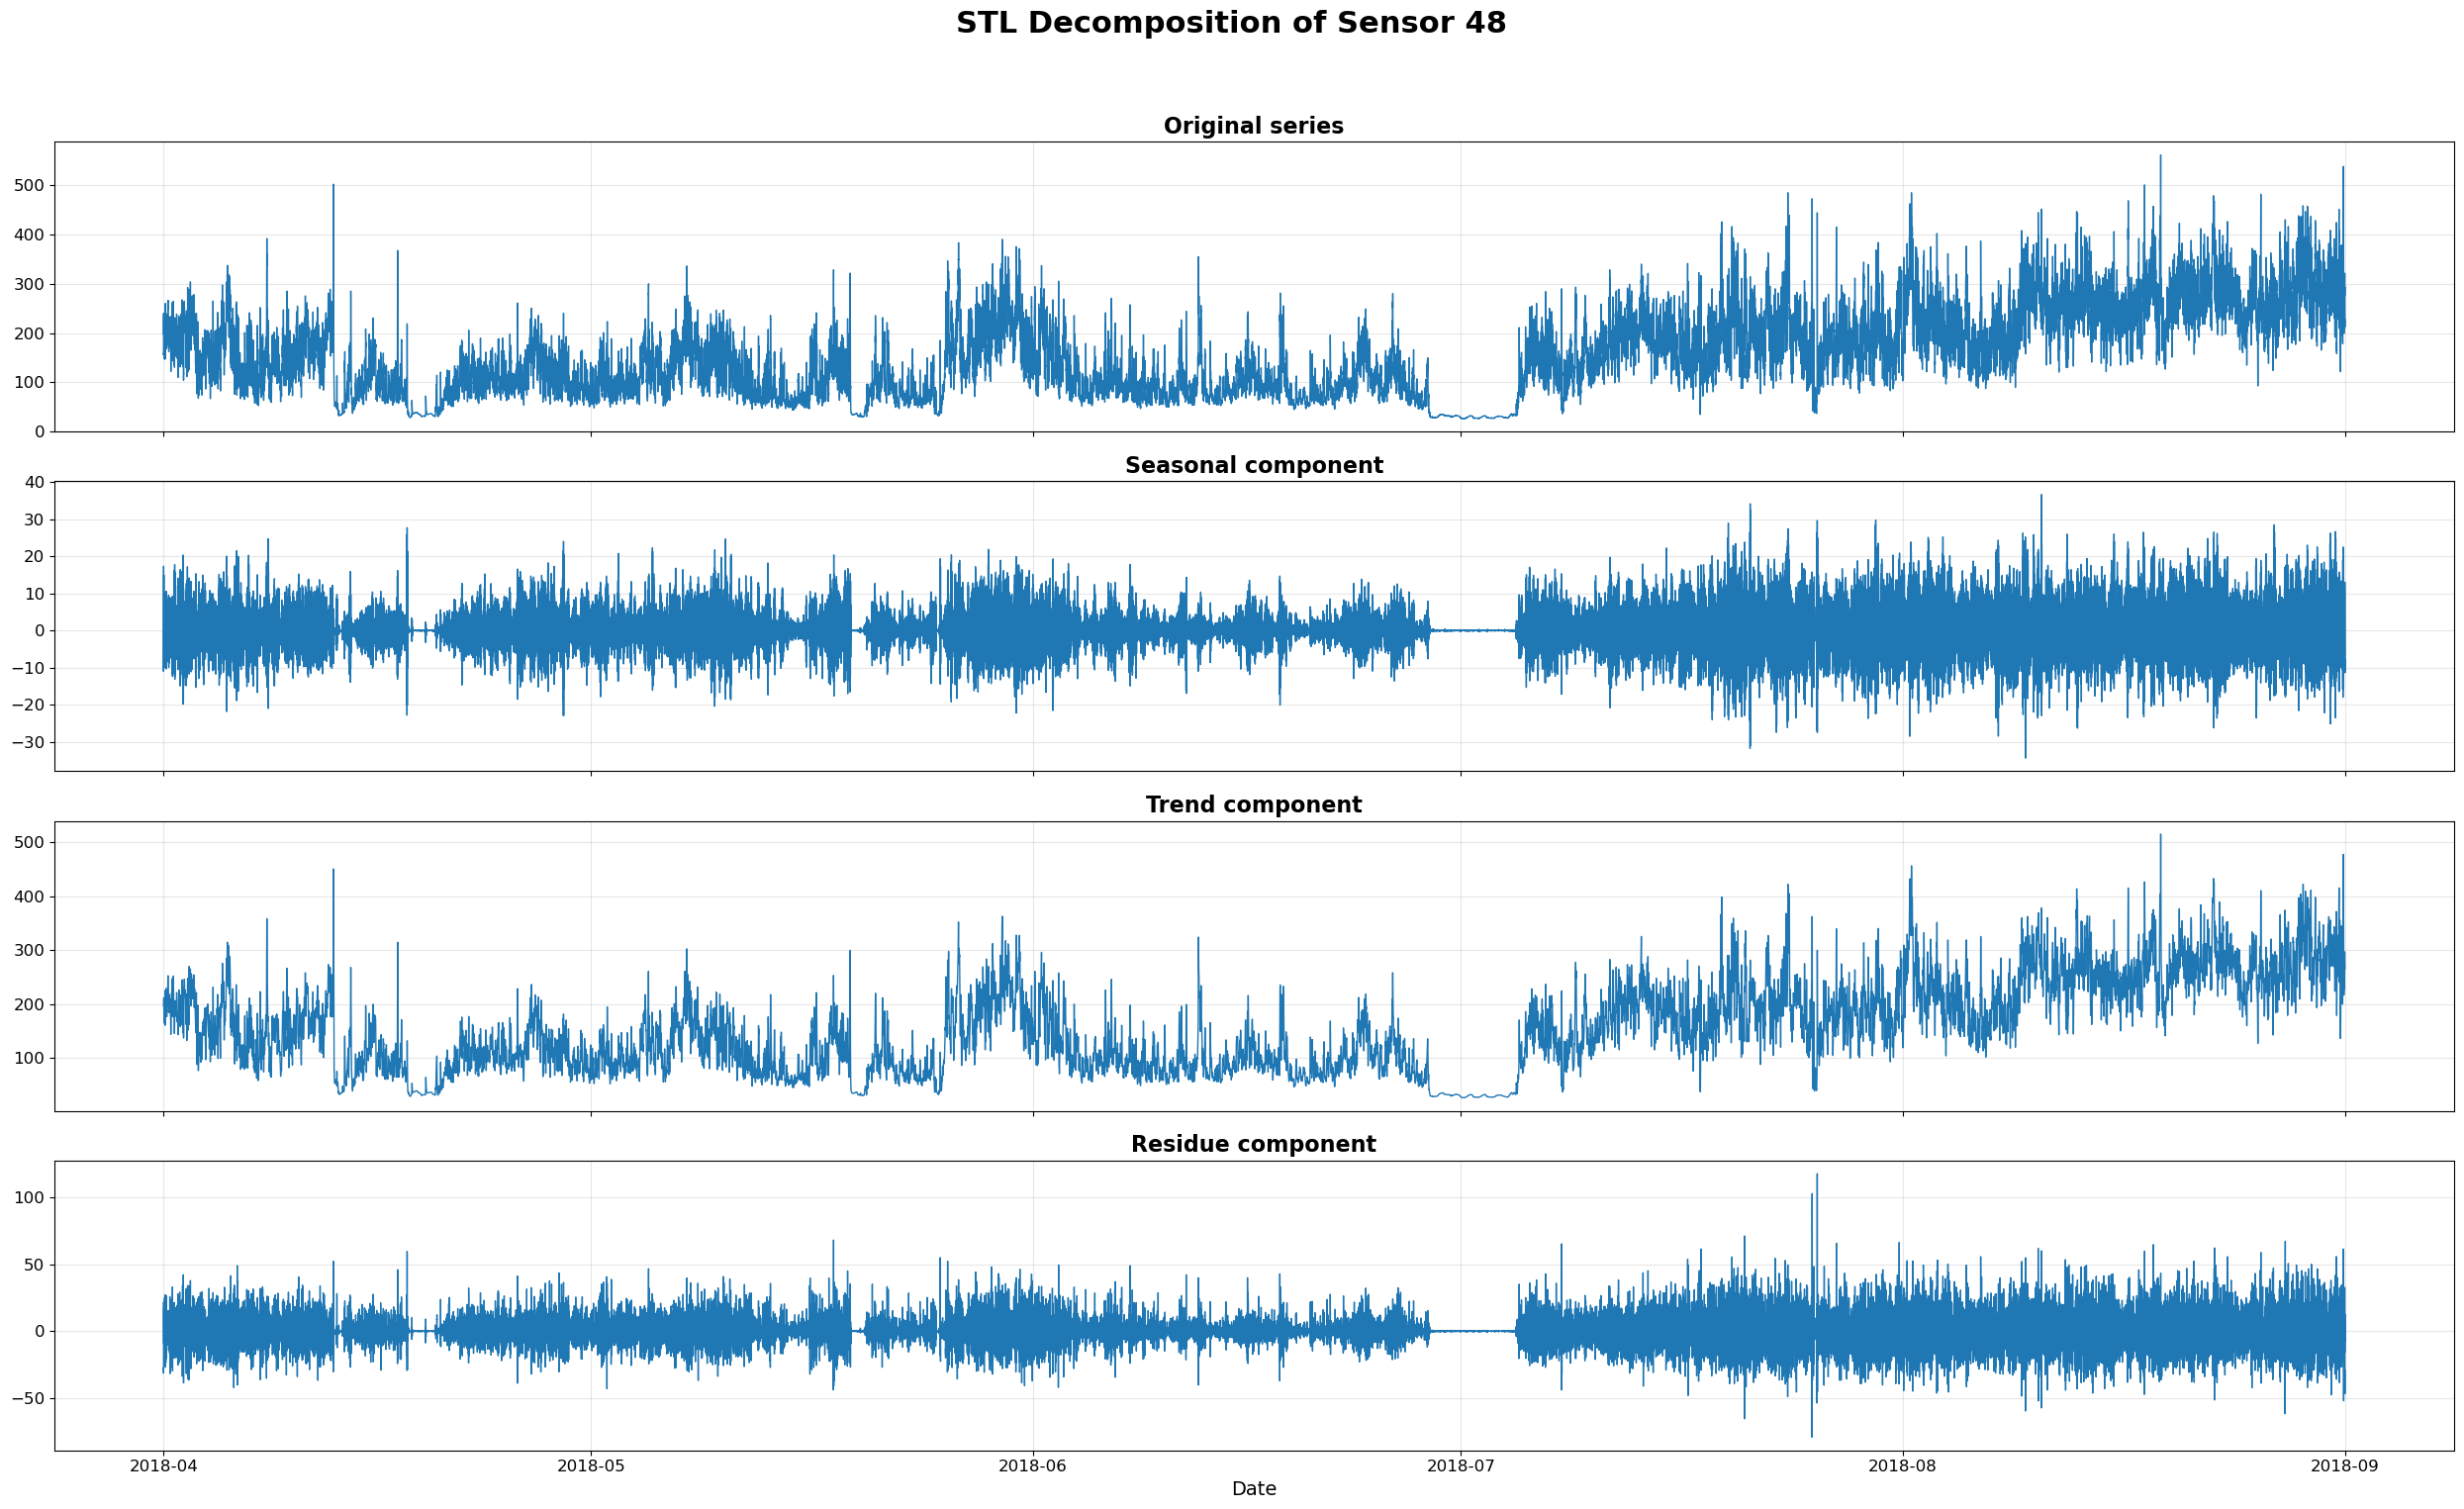

In [28]:
title_list = ['Original series', 'Seasonal component', 'Trend component', 'Residue component']

components = [result.observed, result.seasonal, result.trend, result.resid]

fig, axes = plt.subplots(4, 1, figsize=(25, 16), sharex=True)

for i, (ax, comp, title) in enumerate(zip(axes, components, title_list)):
    ax.plot(comp, linewidth=1, markersize=2)  # Reduce line width and marker size
    ax.set_title(title, fontsize=16, fontweight='bold')
    ax.tick_params(axis='both', labelsize=12)
    ax.grid(True, alpha=0.3)
    if i < 3:
        ax.set_xlabel('')
    else:
        ax.set_xlabel('Date', fontsize=14)

plt.suptitle('STL Decomposition of Sensor 48', fontsize=22, fontweight='bold')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

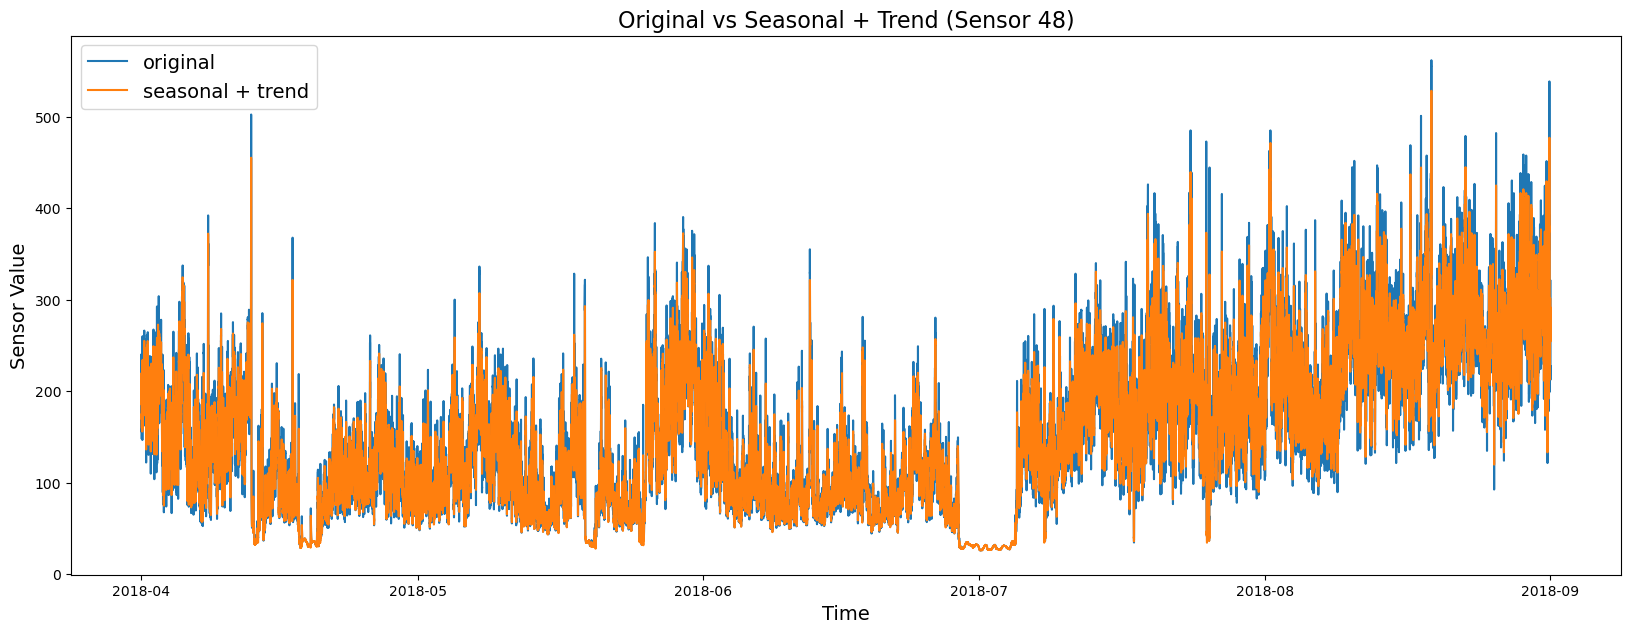

In [29]:
plt.figure(figsize=(20,7))
plt.plot(sensor_series, label="original", zorder=1)
plt.plot(result.trend + result.seasonal, label="seasonal + trend", zorder=2)
plt.title('Original vs Seasonal + Trend (Sensor 48)', fontsize=16)
plt.xlabel('Time', fontsize=14)
plt.ylabel('Sensor Value', fontsize=14)
plt.legend(fontsize=14)
plt.show()

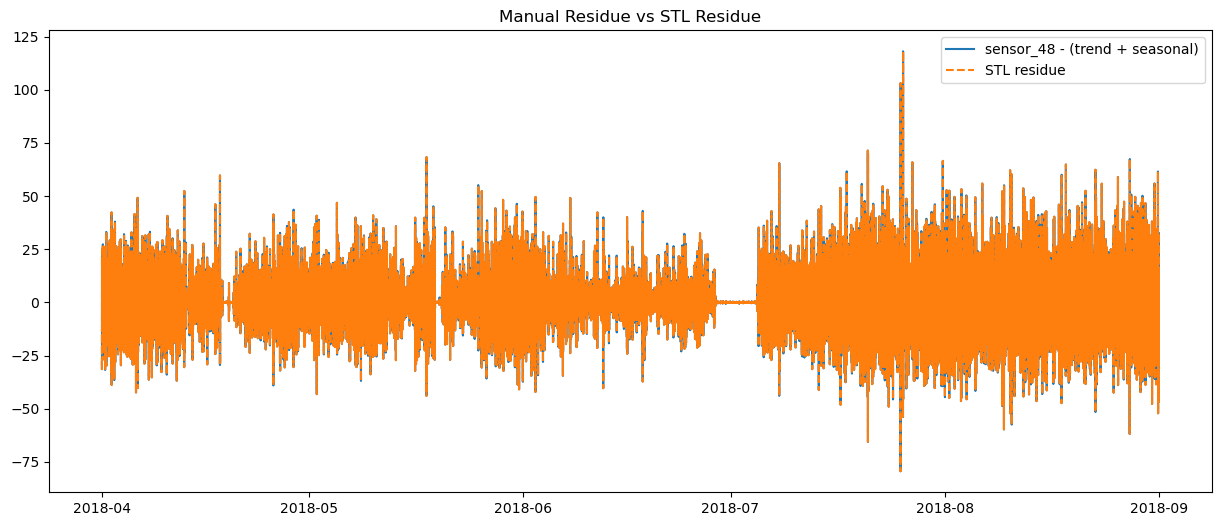

In [30]:
# Compare manual residue calculation with STL residue
manual_resid = sensor_series - (result.trend + result.seasonal)
plt.figure(figsize=(15, 6))
plt.plot(manual_resid, label='sensor_48 - (trend + seasonal)')
plt.plot(result.resid, label='STL residue', linestyle='--')
plt.legend()
plt.title('Manual Residue vs STL Residue')
plt.show()

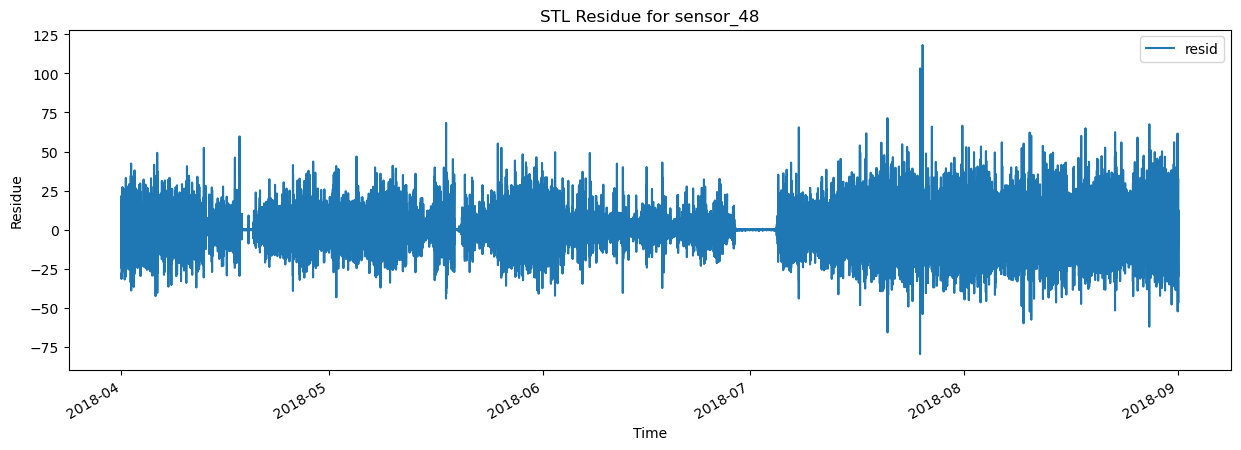

In [31]:
residue_df = pd.DataFrame(result.resid)
residue_df = residue_df.rename(columns={0: 'sensor_48'})  # If the column is unnamed

residue_df.plot(figsize=(15, 5), title='STL Residue for sensor_48')
plt.xlabel('Time')
plt.ylabel('Residue')
plt.show()

Mean value = -0.00, Standard deviation value = 10.03, Cutoff value = 30.09


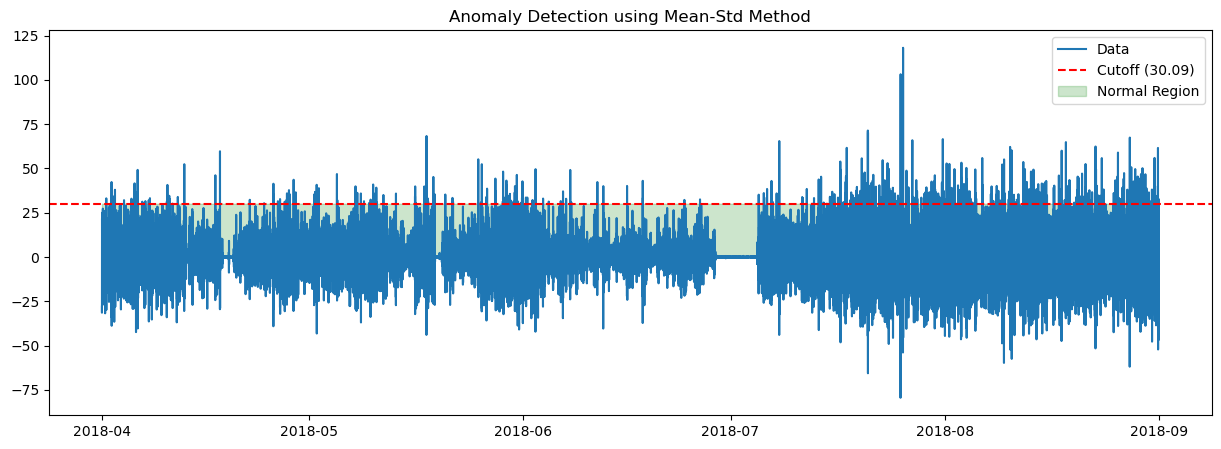

In [32]:
 anomaly_array = detect_anomalies_using_mean_std_method(residue_df, plot_cutoff=True)

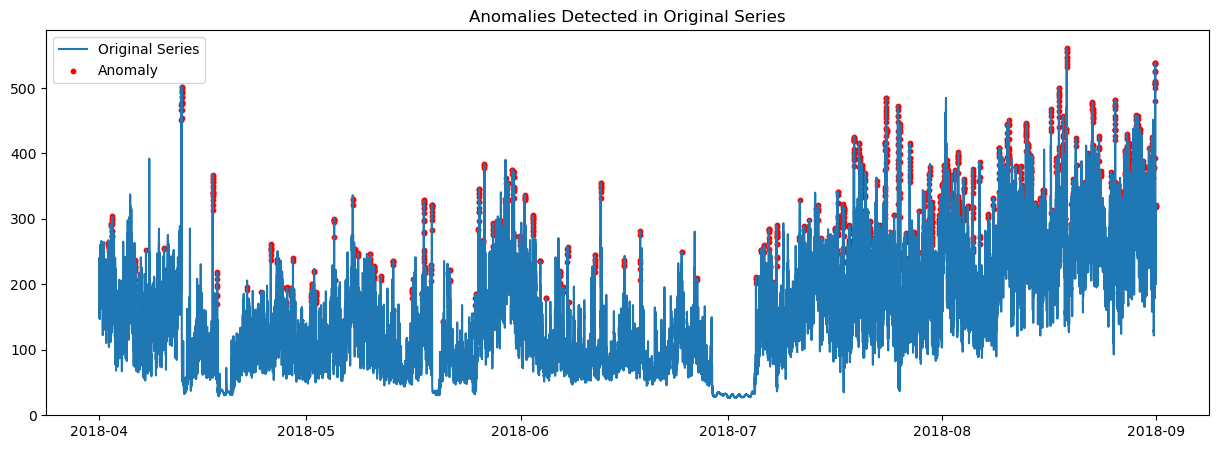

In [33]:
anomaly_indices = residue_df.index[~np.isnan(anomaly_array)]
plt.figure(figsize=(15,5))
plt.plot(sensor_series, label='Original Series')
plt.scatter(anomaly_indices, sensor_series.loc[anomaly_indices], color='red', label='Anomaly', s=10)
plt.legend()
plt.title('Anomalies Detected in Original Series')
plt.show()

EVALUATING SENSOR 48:

ANOMALY DETECTION RESULTS FOR SENSOR_48
Threshold (mean + 3*std): 30.0914
Mean residual: -0.0018
Std residual: 10.0311

Performance Metrics:
Accuracy:  0.9261
Precision: 0.0283
Recall:    0.0037
F1-Score:  0.0066


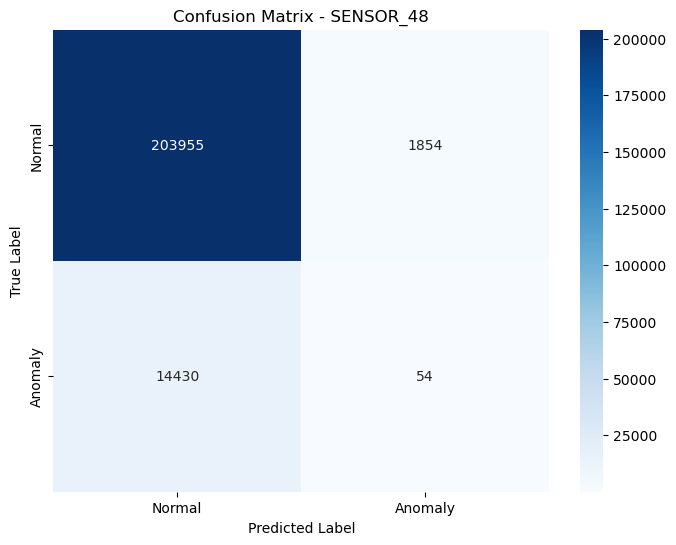


Detailed Classification Report:
              precision    recall  f1-score   support

      Normal       0.93      0.99      0.96    205809
     Anomaly       0.03      0.00      0.01     14484

    accuracy                           0.93    220293
   macro avg       0.48      0.50      0.48    220293
weighted avg       0.87      0.93      0.90    220293



In [34]:
print("EVALUATING SENSOR 48:")
results_sensor_36 = evaluate_stl_anomaly_detection('sensor_48', residue_df, sensor_series, true_anomalies)

In [35]:
# For sensor 48
residue_df_48 = residue_df.copy()

In [36]:
def get_predicted_anomalies(residue_df, threshold):
    residuals = residue_df.iloc[:, 0].values
    return (residuals > threshold).astype(int)

threshold_10 = np.mean(residue_df_10.iloc[:, 0]) + 3 * np.std(residue_df_10.iloc[:, 0])
threshold_36 = np.mean(residue_df_36.iloc[:, 0]) + 3 * np.std(residue_df_36.iloc[:, 0])
threshold_48 = np.mean(residue_df_48.iloc[:, 0]) + 3 * np.std(residue_df_48.iloc[:, 0])

predicted_anomalies_10 = get_predicted_anomalies(residue_df_10, threshold_10)
predicted_anomalies_36 = get_predicted_anomalies(residue_df_36, threshold_36)
predicted_anomalies_48 = get_predicted_anomalies(residue_df_48, threshold_48)

min_len = min(len(true_anomalies), len(predicted_anomalies_10), len(predicted_anomalies_36), len(predicted_anomalies_48))
true_anomalies_aligned = true_anomalies[:min_len]
predicted_anomalies_10 = predicted_anomalies_10[:min_len]
predicted_anomalies_36 = predicted_anomalies_36[:min_len]
predicted_anomalies_48 = predicted_anomalies_48[:min_len]

def get_classification_report_df(y_true, y_pred, sensor_name):
    report = classification_report(y_true, y_pred, output_dict=True, zero_division=0)
    df = pd.DataFrame(report).transpose()
    df['sensor'] = sensor_name
    # Add number of anomalies found
    df['anomalies_found'] = np.sum(y_pred) if '1' in df.index else 0
    return df

report_10 = get_classification_report_df(true_anomalies_aligned, predicted_anomalies_10, 'sensor_10')
report_36 = get_classification_report_df(true_anomalies_aligned, predicted_anomalies_36, 'sensor_36')
report_48 = get_classification_report_df(true_anomalies_aligned, predicted_anomalies_48, 'sensor_48')

combined_report = pd.concat([report_10, report_36, report_48])

cols = ['sensor', 'anomalies_found'] + [col for col in combined_report.columns if col not in ['sensor', 'anomalies_found']]
combined_report = combined_report[cols]

main_metrics = combined_report.loc[['0', '1', 'accuracy']]
print(main_metrics)

print('\nNumber of anomalies detected by each sensor:')
for sensor, preds in zip(['sensor_10', 'sensor_36', 'sensor_48'],
                         [predicted_anomalies_10, predicted_anomalies_36, predicted_anomalies_48]):
    print(f"{sensor}: {np.sum(preds)}")

             sensor  anomalies_found  precision    recall  f1-score  \
0         sensor_10             1553   0.933931  0.992610  0.962377   
0         sensor_36             1489   0.934370  0.993368  0.962966   
0         sensor_48             1908   0.933924  0.990992  0.961612   
1         sensor_10             1553   0.020605  0.002209  0.003991   
1         sensor_36             1489   0.083277  0.008561  0.015526   
1         sensor_48             1908   0.028302  0.003728  0.006589   
accuracy  sensor_10             1553   0.927492  0.927492  0.927492   
accuracy  sensor_36             1489   0.928618  0.928618  0.928618   
accuracy  sensor_48             1908   0.926080  0.926080  0.926080   

                support  
0         205809.000000  
0         205809.000000  
0         205809.000000  
1          14484.000000  
1          14484.000000  
1          14484.000000  
accuracy       0.927492  
accuracy       0.928618  
accuracy       0.926080  

Number of anomalies detected

| Disadvantage                    | Description                                                        |
|----------------------------------|--------------------------------------------------------------------|
| Additive assumption              | Struggles with multiplicative or nonlinear effects                 |
| Not a direct anomaly detector    | Needs post-processing for anomaly detection                        |
| Sensitive to outliers            | Outliers can distort trend/seasonal estimates                      |
| Needs regular time series        | Irregular/missing data can cause problems                          |
| Parameter tuning required        | Poor window choices can degrade results                            |
| Computational cost               | LOESS smoothing is slow for large datasets                         |
| Univariate only                  | Cannot model relationships between multiple variables              |
| Limited for complex seasonality  | May not adapt to rapidly changing patterns                         |
| Thresholding issues              | Simple thresholds may not suit all data distributions              |